In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve


In [2]:
df = pd.read_csv("dataset_12000_records.csv")

df.head()
df.shape
df.columns
df.info()

# Descriptive Statistics
df.describe()

# Target distribution
df["Readmitted_30_Days"].value_counts()
df["Readmitted_30_Days"].value_counts(normalize=True) * 100



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12000 non-null  object 
 1   Age                           12000 non-null  int64  
 2   Gender                        12000 non-null  object 
 3   BMI                           12000 non-null  float64
 4   Smoking_Status                12000 non-null  object 
 5   Alcohol_Consumption           12000 non-null  object 
 6   Exercise_Frequency            12000 non-null  int64  
 7   Hypertension                  12000 non-null  int64  
 8   Diabetes                      12000 non-null  int64  
 9   Chronic_Kidney_Disease        12000 non-null  int64  
 10  Coronary_Artery_Disease       12000 non-null  int64  
 11  Previous_Stroke               12000 non-null  int64  
 12  Atrial_Fibrillation           12000 non-null  int64  
 13  P

,proportion
Readmitted_30_Days,
0,70.0
1,30.0


In [3]:
# Missing values

df.isnull().sum()

# Drop ID
df = df.drop("Patient_ID", axis=1 , errors= "ignore")

# Find categorical columns
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(df,columns=categorical_cols,drop_first=True,dtype=int)


# Rechecking
# df.dtypes



In [4]:
# Separate features and target

X = df.drop("Readmitted_30_Days",axis=1)
y = df["Readmitted_30_Days"]


# Split the data

X_train , X_test , y_train, y_test = train_test_split( X, y, test_size=0.3,random_state=42, stratify=y )
# stratify = y helps us keep the same proportion of the target classes in both the training and testing data.


# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:

# Train Logistic Regression

model = LogisticRegression(max_iter=1000 , random_state=42)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Probability for ROC-AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


# Training predictions

y_train_pred = model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)


Logistic Regression
Accuracy : 0.8922222222222222
Precision: 0.8412228796844181
Recall   : 0.7898148148148149
F1 Score : 0.8147086914995224
ROC-AUC  : 0.9549496619635507
Train Accuracy: 0.8964285714285715
Test Accuracy : 0.8922222222222222
[[2359  161]
 [ 227  853]]


In [6]:
# Train KNN model

param_grid = { "n_neighbors": [3, 5, 7, 9, 11, 15, 21] }

knn = KNeighborsClassifier()

# Find the best k using CV

grid_search = GridSearchCV(knn, param_grid, cv=5 , scoring="f1")

grid_search.fit(X_train_scaled, y_train)

print("Best k:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)


# Train the final model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predictions and probabilities
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]


# Metrices
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Model")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)
print("ROC-AUC  :", roc_auc_knn)
print("Confusion Matrix:",cm_knn)

# Train and Test accuracy

y_train_pred_knn = knn_model.predict(X_train_scaled)

train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)

print("Train Accuracy:", train_accuracy_knn)
print("Test Accuracy :", accuracy_knn)

Best k: {'n_neighbors': 5}
Best CV F1: 0.6931817661685761
KNN Model
Accuracy : 0.84
Precision: 0.8272727272727273
Recall   : 0.5898148148148148
F1 Score : 0.6886486486486486
ROC-AUC  : 0.8796145649617872
Confusion Matrix: [[2387  133]
 [ 443  637]]
Train Accuracy: 0.8886904761904761
Test Accuracy : 0.84


In [7]:
# Train Decision Trees

# Tune the tree

param_grid_tree = {"max_depth": [2, 3, 4, 5, 6, 8, 10, None]}

tree = DecisionTreeClassifier(random_state=42)

grid_search_tree = GridSearchCV(
    tree,
    param_grid_tree,
    cv=5,
    scoring="f1"
)

grid_search_tree.fit(X_train, y_train)

print("Best max_depth:", grid_search_tree.best_params_)
print("Best CV F1:", grid_search_tree.best_score_)


# Final Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predictions and Probability

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1 Score :", f1_tree)
print("ROC-AUC  :", roc_auc_tree)
print("Confusion Matrix:",cm_tree)

# Training predictions
y_train_pred_tree = tree_model.predict(X_train)

train_accuracy_tree = accuracy_score(y_train, y_train_pred_tree)

print("Train Accuracy:", train_accuracy_tree)
print("Test Accuracy :", accuracy_tree)

Best max_depth: {'max_depth': 5}
Best CV F1: 0.7064741343203829
Decision Tree
Accuracy : 0.8402777777777778
Precision: 0.7579162410623085
Recall   : 0.687037037037037
F1 Score : 0.7207382224380767
ROC-AUC  : 0.8889568636096414
Confusion Matrix: [[2283  237]
 [ 338  742]]
Train Accuracy: 0.8547619047619047
Test Accuracy : 0.8402777777777778


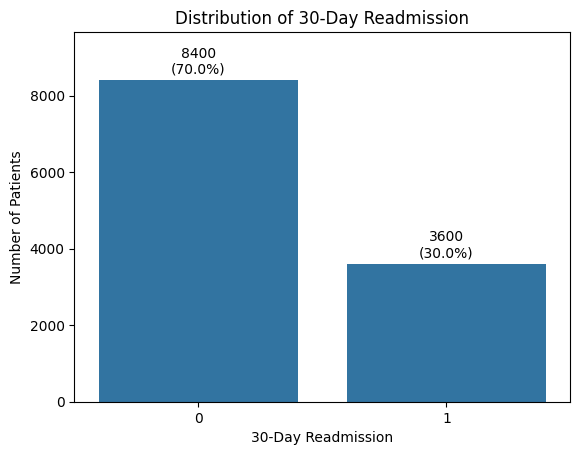

In [8]:
# Visualizations

sns.countplot(x="Readmitted_30_Days", data=df)

plt.xlabel("30-Day Readmission")
plt.ylabel("Number of Patients")
plt.title("Distribution of 30-Day Readmission")

total = len(df)

for bar in plt.gca().patches:
    count = int(bar.get_height())
    percentage = (count / total) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 100,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(df["Readmitted_30_Days"].value_counts()) * 1.15)
plt.show()
# It is asking a simple question- how many patients were readmitted within 30 days and how many were not
# 0 → Not Readmitted
# 1 → Readmitted

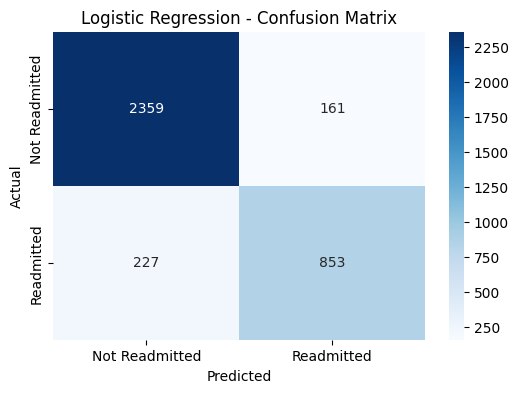

In [9]:
# 2. Logistic Regression - Confusion Matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

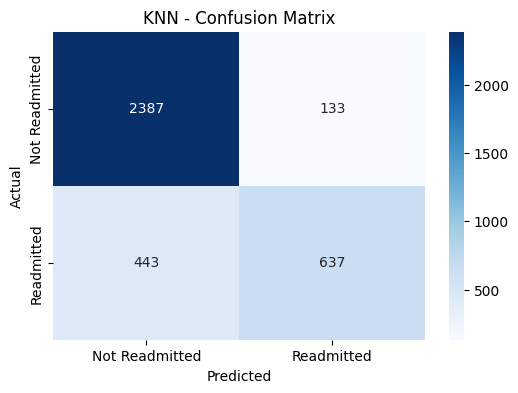

In [10]:
# KNN - Confusion Matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")

plt.show()

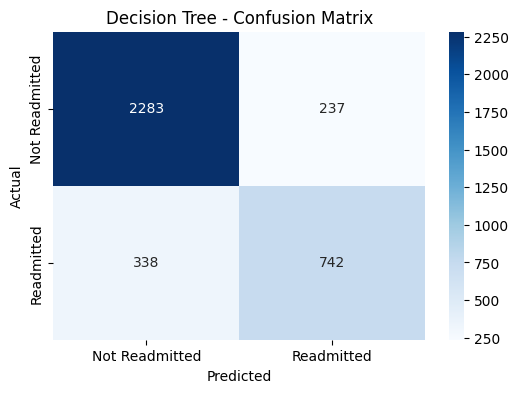

In [11]:
# Decision Tree - Confusion Matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

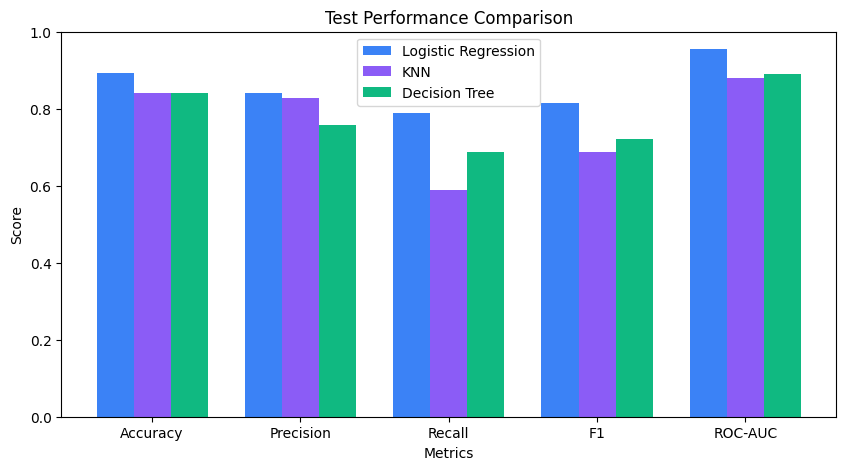

In [12]:
# 3. Test Metrics Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

logistic_scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

knn_scores = [
    accuracy_knn,
    precision_knn,
    recall_knn,
    f1_knn,
    roc_auc_knn
]

tree_scores = [
    accuracy_tree,
    precision_tree,
    recall_tree,
    f1_tree,
    roc_auc_tree
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - width, logistic_scores, width, label="Logistic Regression" , color="#3B82F6")
plt.bar(x, knn_scores, width, label="KNN" , color= "#8B5CF6")
plt.bar(x + width, tree_scores, width, label="Decision Tree" , color="#10B981")


plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Test Performance Comparison")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

plt.show()

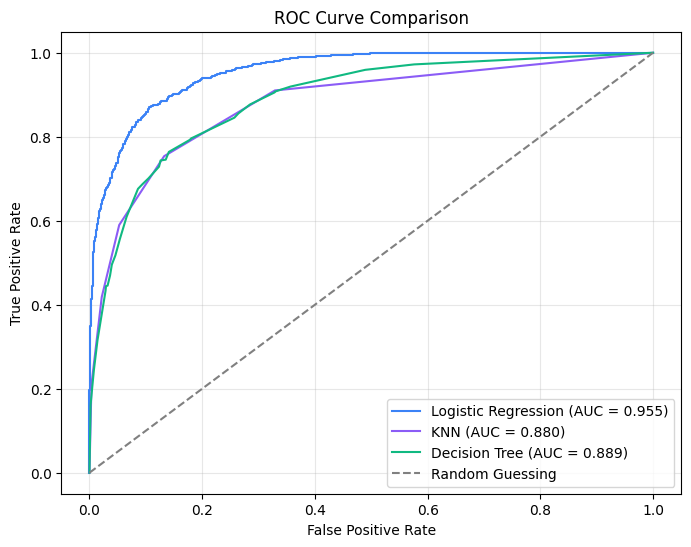

In [13]:
# Calculate ROC curve points
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})",
    color="#3B82F6"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {roc_auc_knn:.3f})",
    color="#8B5CF6"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {roc_auc_tree:.3f})",
    color="#10B981"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

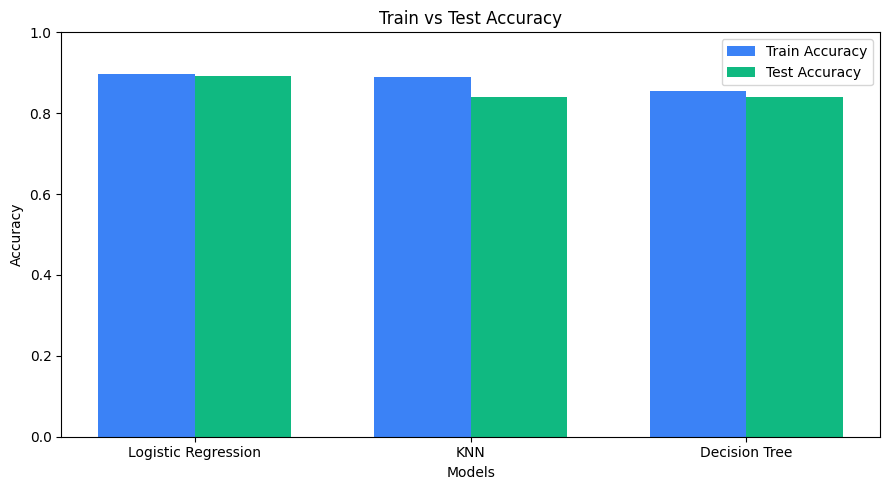

In [14]:
models = ["Logistic Regression", "KNN", "Decision Tree"]

train_scores = [
    train_accuracy,
    train_accuracy_knn,
    train_accuracy_tree
]

test_scores = [
    accuracy,
    accuracy_knn,
    accuracy_tree
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    train_scores,
    width,
    label="Train Accuracy",
    color="#3B82F6"
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label="Test Accuracy",
    color="#10B981"
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()